# Get expression matrix

In [15]:
import pandas as pd

proteome = pd.read_csv("../data/raw/proteomic/proteome_imputed.tsv",sep="\t")

proteome = proteome.set_index("gene")
proteome = proteome.drop(columns=["refseq_id"])

proteome.describe()

,C3L-00104,C3L-00365,C3L-00674,C3L-00677,C3L-01040,C3L-01043,C3L-01045,C3L-01046,C3L-01048,C3L-01049,...,PT-NPJ7,PT-P44H,PT-Q2AG,PT-QVJO,PT-R55F,PT-RN5K,PT-RU72,PT-UTHO,PT-WVLH,PT-Y8DK
count,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,...,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000
mean,0.011871,-0.042128,0.065560,0.043825,0.011158,0.007011,-0.019791,0.014513,-0.030062,-0.014379,...,0.212444,0.186822,0.213447,0.214324,0.186166,0.183888,0.180634,0.215678,0.198933,0.212333
std,0.398464,0.519172,0.484682,0.491390,0.459679,0.540076,0.636358,0.625826,0.539239,0.505644,...,1.124159,1.047652,1.147825,1.100425,1.032947,1.028260,1.032960,1.138039,1.077398,0.983133
min,-2.657711,-4.351911,-4.042548,-2.704767,-2.972341,-2.771862,-5.557296,-2.427878,-6.637013,-4.134884,...,-4.250483,-3.988596,-3.850057,-3.841200,-4.318241,-4.412635,-3.958472,-4.798275,-4.617543,-3.548880
25%,-0.214137,-0.275860,-0.206297,-0.236896,-0.236898,-0.261292,-0.325196,-0.332010,-0.306827,-0.285646,...,-0.553309,-0.510583,-0.566653,-0.555937,-0.494017,-0.512372,-0.512621,-0.559916,-0.526732,-0.448280
50%,-0.009111,0.001024,0.017964,0.011271,-0.006335,0.010394,0.012342,-0.015217,-0.001970,-0.011199,...,-0.010831,-0.002648,-0.010050,0.013092,-0.002171,0.003449,-0.028826,0.008523,-0.000431,0.013485
75%,0.206262,0.246491,0.280381,0.281016,0.237255,0.237951,0.309377,0.319180,0.300801,0.230133,...,0.777137,0.719674,0.803101,0.800842,0.725325,0.720828,0.690007,0.815056,0.771391,0.721034
max,3.520582,2.516254,3.133515,4.343769,3.433517,3.619684,5.607979,4.514111,3.923987,3.750830,...,5.199594,4.477295,4.788296,4.570630,4.175174,5.194838,4.744290,5.068041,4.562353,4.036980


# Get metadata

In [16]:
clin = pd.read_csv("../data/raw/proteomic/all_subtypes.v5.1.tsv",sep="\t")
clin
tumor_id = clin[clin["sample_type"] == "tumor"]["case"].tolist()
normal_id = clin[clin["sample_type"] == "GTEx normal"]["case"].tolist()
normal_id

['PT-NPJ7',
 'PT-P44H',
 'PT-Q2AG',
 'PT-QVJO',
 'PT-R55F',
 'PT-RN5K',
 'PT-RU72',
 'PT-UTHO',
 'PT-WVLH',
 'PT-Y8DK']

# Split into tumor and normal expression matrix

In [17]:
gbm_expr = proteome[tumor_id]
control_expr = proteome[normal_id]
control_expr

,PT-NPJ7,PT-P44H,PT-Q2AG,PT-QVJO,PT-R55F,PT-RN5K,PT-RU72,PT-UTHO,PT-WVLH,PT-Y8DK
gene,,,,,,,,,,
A1BG,-1.717510,-1.357500,-1.528595,-1.539841,-1.789458,-1.624156,-1.452245,-1.902994,-2.003926,-1.590282
A2M,-1.064325,-0.806817,-1.511272,-1.247939,-1.478376,-1.163916,-1.147384,-1.162469,-1.605927,-1.227305
AAAS,-0.306516,-0.580316,-0.710189,-0.672322,-0.764798,-0.570896,-0.373231,-0.411892,-0.694845,-0.487413
AACS,0.436075,0.556105,0.888602,0.916637,0.857309,0.608478,0.584371,0.534934,0.817702,0.866017
AADAT,1.316010,1.429100,1.337539,1.630508,1.157699,0.756814,1.040895,1.230606,0.644152,1.033949
...,...,...,...,...,...,...,...,...,...,...
ZXDC,0.164100,0.517515,-0.076385,-1.330917,0.080553,-0.007176,-0.073908,1.278683,-0.233022,-0.250798
ZYG11B,0.767921,0.379683,0.791386,0.667393,0.563370,0.609314,0.637394,0.616285,0.732273,0.623839
ZYX,-1.128100,-1.087567,-0.667928,-1.172195,-0.973314,-1.293464,-0.795886,-0.734952,-1.158899,-0.892930


In [19]:
log2fc = (
    gbm_expr.mean(axis=1)
    - control_expr.mean(axis=1)
)

from scipy.stats import ttest_ind

pvals = []

for gene in proteome.index:
    _, p = ttest_ind(
        gbm_expr.loc[gene],
        control_expr.loc[gene],
        equal_var=False,
        nan_policy="omit"
    )
    pvals.append(p)
    

from statsmodels.stats.multitest import multipletests

fdr = multipletests(pvals, method="fdr_bh")[1]


results = pd.DataFrame({
    "log2FC": log2fc,
    "pvalue": pvals,
    "adjustedpvalue": fdr
}, index=proteome.index)

import numpy as np

results["-log(adjustedp)"] = -np.log10(results["adjustedpvalue"])

In [20]:

results.to_csv("../data/processed/de_proteome.csv")

In [21]:
results

,log2FC,pvalue,adjustedpvalue,-log(adjustedp)
gene,,,,
A1BG,1.751663,1.740332e-19,1.649829e-18,17.782561
A2M,1.446368,2.631714e-14,1.480730e-13,12.829524
AAAS,0.603250,5.753307e-08,1.502036e-07,6.823320
AACS,-0.747064,8.155613e-09,2.376589e-08,7.624046
AADAT,-1.181237,7.377722e-08,1.893361e-07,6.722767
...,...,...,...,...
ZXDC,-0.051378,8.127155e-01,8.287182e-01,0.081593
ZYG11B,-0.642655,5.650706e-12,2.446680e-11,10.611423
ZYX,1.046176,1.121758e-11,4.672422e-11,10.330458


# PCA

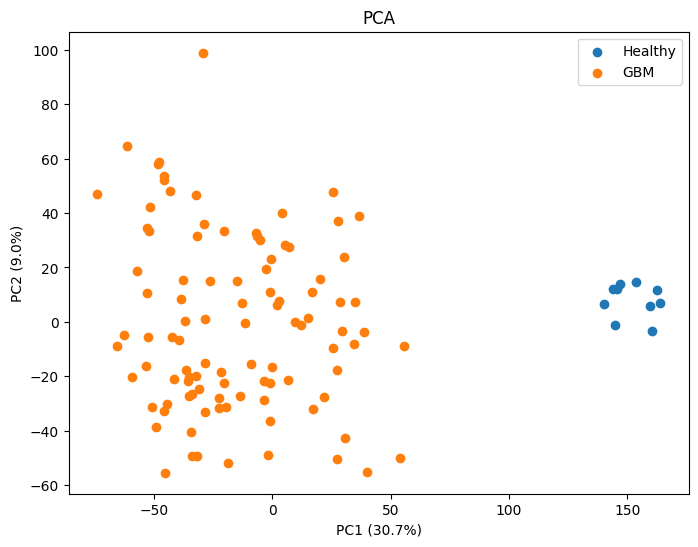

In [22]:
expr = pd.concat([control_expr, gbm_expr], axis=1)

labels = (
    ["Healthy"] * control_expr.shape[1] +
    ["GBM"] * gbm_expr.shape[1]
)

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import pandas as pd
import matplotlib.pyplot as plt

X = expr.T

X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2)
pcs = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    pcs,
    columns=["PC1", "PC2"]
)

pca_df["Group"] = labels

plt.figure(figsize=(8,6))

for group in ["Healthy", "GBM"]:
    mask = pca_df["Group"] == group
    plt.scatter(
        pca_df.loc[mask, "PC1"],
        pca_df.loc[mask, "PC2"],
        label=group
    )

plt.xlabel(
    f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)"
)
plt.ylabel(
    f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)"
)
plt.legend()
plt.title("PCA")
plt.show()

# Volcano

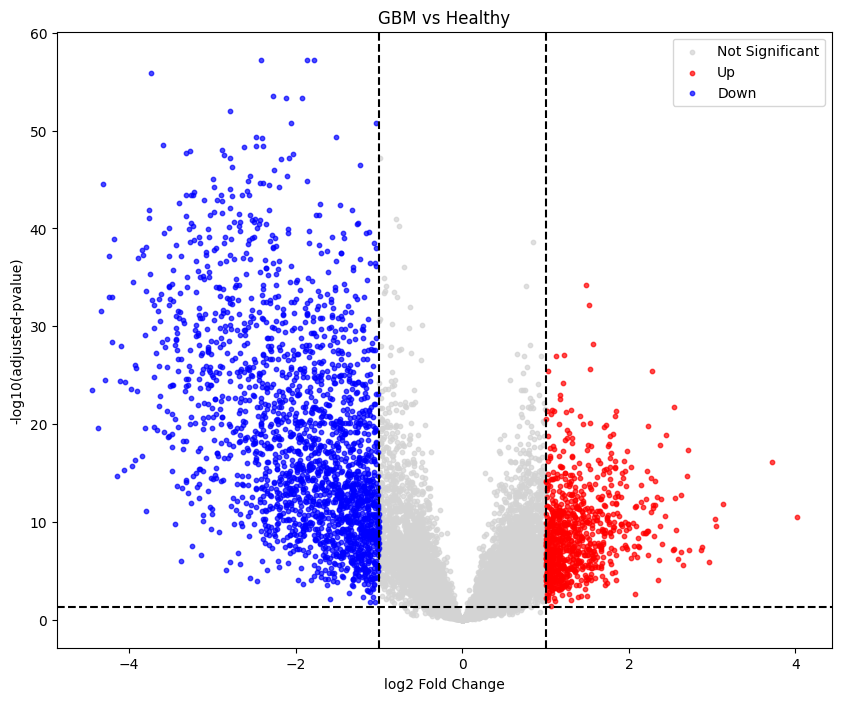

In [23]:
import numpy as np
import matplotlib.pyplot as plt



results["category"] = "Not Significant"
results.loc[
    (results["adjustedpvalue"] < 0.05) & (results["log2FC"] > 1),
    "category"
] = "Up"

results.loc[
    (results["adjustedpvalue"] < 0.05) & (results["log2FC"] < -1),
    "category"
] = "Down"

colors = {
    "Up": "red",
    "Down": "blue",
    "Not Significant": "lightgray"
}

plt.figure(figsize=(10, 8))

for cat in ["Not Significant", "Up", "Down"]:
    subset = results[results["category"] == cat]

    plt.scatter(
        subset["log2FC"],
        subset["-log(adjustedp)"],
        c=colors[cat],
        label=cat,
        s=10,
        alpha=0.7
    )

plt.axvline(1, linestyle="--", color="black")
plt.axvline(-1, linestyle="--", color="black")
plt.axhline(-np.log10(0.05), linestyle="--", color="black")

plt.xlabel("log2 Fold Change")
plt.ylabel("-log10(adjusted-pvalue)")
plt.title("GBM vs Healthy")
plt.legend()
plt.show()